# Monte Carlo-Based Portfolio Risk & Optimization Analysis
Objective

Construct and analyze a multi-asset portfolio using classical portfolio optimization, then use Monte Carlo simulation to evaluate the uncertainty and risk of the resulting portfolio.

In [2]:
# Install
!pip install yfinance -q

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
tickers = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA",
    "META",
    "JPM",
    "JNJ"
]

start_date = "2019-01-01"
end_date = "2024-01-01"

In [5]:
prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

In [6]:
prices.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Date,,,,,,,,
2019-01-02,37.436905,76.956497,52.236931,103.281593,80.473999,134.392807,94.016144,3.369282
2019-01-03,33.707920,75.014000,50.790192,101.640411,79.330307,130.490189,90.557503,3.165720
2019-01-04,35.146885,78.769501,53.395405,103.346291,82.254837,136.641296,94.769249,3.368540
2019-01-07,35.068661,81.475502,53.288918,102.683357,82.312042,136.740341,94.890114,3.546873
2019-01-08,35.737183,82.829002,53.756966,105.068321,82.156822,141.177826,95.578148,3.458571


In [7]:
prices.tail()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Date,,,,,,,,
2023-12-22,191.268127,153.419998,140.156326,143.899094,157.864822,350.037445,366.750336,48.688877
2023-12-26,190.724762,153.410004,140.186035,144.528534,158.798462,351.463745,366.828735,49.136578
2023-12-27,190.823547,153.339996,139.046875,144.722900,159.750946,354.435333,366.251099,49.274185
2023-12-28,191.248383,153.380005,138.908203,144.935822,160.599701,354.920654,367.435699,49.378876
2023-12-29,190.211029,151.940002,138.373291,145.083923,160.411087,350.602020,368.179901,49.378876


In [8]:
prices.shape

(1258, 8)

In [9]:
prices.isna().sum()

,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
JNJ,0
JPM,0
META,0
MSFT,0
NVDA,0


In [10]:
#Handle missing observations
prices = prices.dropna()

In [11]:
print("Start:", prices.index.min())
print("End:", prices.index.max())
print("Observations:", len(prices))
print("Assets:", prices.shape[1])

Start: 2019-01-02 00:00:00
End: 2023-12-29 00:00:00
Observations: 1258
Assets: 8


In [12]:
# daily return
returns = prices.pct_change().dropna()

In [13]:
returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Date,,,,,,,,
2019-01-03,-0.099607,-0.025241,-0.027696,-0.015890,-0.014212,-0.029039,-0.036788,-0.060417
2019-01-04,0.042689,0.050064,0.051294,0.016783,0.036865,0.047138,0.046509,0.064067
2019-01-07,-0.002226,0.034353,-0.001994,-0.006415,0.000695,0.000725,0.001275,0.052941
2019-01-08,0.019063,0.016612,0.008783,0.023226,-0.001886,0.032452,0.007251,-0.024896
2019-01-09,0.016982,0.001714,-0.003427,-0.007926,-0.001690,0.011928,0.014299,0.019667


In [14]:
returns.describe()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,0.001500,0.000787,0.000976,0.000349,0.000750,0.001147,0.001271,0.002666
std,0.020306,0.022187,0.020038,0.012513,0.020094,0.027484,0.019207,0.032612
min,-0.128647,-0.140494,-0.116341,-0.072984,-0.149649,-0.263901,-0.147391,-0.184521
25%,-0.008204,-0.010856,-0.008504,-0.005618,-0.008411,-0.011457,-0.008308,-0.015158
50%,0.001423,0.000955,0.001013,0.000283,0.000671,0.001051,0.001250,0.003054
75%,0.012431,0.012076,0.011037,0.006199,0.009649,0.014326,0.011154,0.019810
max,0.119808,0.135359,0.096202,0.079977,0.180125,0.232824,0.142169,0.243696


In [15]:
# ---------------------------------------------------------
# 1. Basic structure of the price data
# ---------------------------------------------------------

print("Price data shape:", prices.shape)
print("\nDate range:")
print(prices.index.min(), "to", prices.index.max())

print("\nData types:")
print(prices.dtypes)

print("\nMissing values:")
print(prices.isna().sum())

print("\nDuplicate dates:", prices.index.duplicated().sum())

Price data shape: (1258, 8)

Date range:
2019-01-02 00:00:00 to 2023-12-29 00:00:00

Data types:
Ticker
AAPL     float64
AMZN     float64
GOOGL    float64
JNJ      float64
JPM      float64
META     float64
MSFT     float64
NVDA     float64
dtype: object

Missing values:
Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
META     0
MSFT     0
NVDA     0
dtype: int64

Duplicate dates: 0


In [16]:
# ---------------------------------------------------------
# Calculate simple daily returns
# ---------------------------------------------------------
# Return = (Today's Price / Yesterday's Price) - 1

returns = prices.pct_change().dropna()

print("Return data shape:", returns.shape)
returns.head()

Return data shape: (1257, 8)


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Date,,,,,,,,
2019-01-03,-0.099607,-0.025241,-0.027696,-0.015890,-0.014212,-0.029039,-0.036788,-0.060417
2019-01-04,0.042689,0.050064,0.051294,0.016783,0.036865,0.047138,0.046509,0.064067
2019-01-07,-0.002226,0.034353,-0.001994,-0.006415,0.000695,0.000725,0.001275,0.052941
2019-01-08,0.019063,0.016612,0.008783,0.023226,-0.001886,0.032452,0.007251,-0.024896
2019-01-09,0.016982,0.001714,-0.003427,-0.007926,-0.001690,0.011928,0.014299,0.019667


In [17]:
# Check for missing values after calculating returns
print("Missing values in returns:")
print(returns.isna().sum())

Missing values in returns:
Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
META     0
MSFT     0
NVDA     0
dtype: int64


In [18]:
# ---------------------------------------------------------
# Calculate basic statistics of daily returns
# ---------------------------------------------------------

daily_mean = returns.mean()
daily_std = returns.std()

summary = pd.DataFrame({
    "Mean Daily Return": daily_mean,
    "Daily Volatility": daily_std
})

summary

,Mean Daily Return,Daily Volatility
Ticker,,
AAPL,0.001500,0.020306
AMZN,0.000787,0.022187
GOOGL,0.000976,0.020038
JNJ,0.000349,0.012513
JPM,0.000750,0.020094
META,0.001147,0.027484
MSFT,0.001271,0.019207
NVDA,0.002666,0.032612


In [19]:
# ---------------------------------------------------------
# Annualize return and volatility
# ---------------------------------------------------------

annual_return = daily_mean * 252
annual_volatility = daily_std * np.sqrt(252)

summary = pd.DataFrame({
    "Annualized Return": annual_return,
    "Annualized Volatility": annual_volatility
})

summary

,Annualized Return,Annualized Volatility
Ticker,,
AAPL,0.378031,0.322345
AMZN,0.198360,0.352214
GOOGL,0.245988,0.318100
JNJ,0.087829,0.198633
JPM,0.189011,0.318977
META,0.289079,0.436300
MSFT,0.320295,0.304908
NVDA,0.671826,0.517699


In [20]:
# ---------------------------------------------------------
# Correlation matrix
# ---------------------------------------------------------

correlation_matrix = returns.corr()

correlation_matrix.round(2)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Ticker,,,,,,,,
AAPL,1.00,0.62,0.67,0.41,0.45,0.59,0.76,0.66
AMZN,0.62,1.00,0.66,0.23,0.28,0.61,0.68,0.60
GOOGL,0.67,0.66,1.00,0.35,0.44,0.67,0.76,0.63
JNJ,0.41,0.23,0.35,1.00,0.41,0.24,0.42,0.23
JPM,0.45,0.28,0.44,0.41,1.00,0.33,0.45,0.38
META,0.59,0.61,0.67,0.24,0.33,1.00,0.62,0.55
MSFT,0.76,0.68,0.76,0.42,0.45,0.62,1.00,0.71
NVDA,0.66,0.60,0.63,0.23,0.38,0.55,0.71,1.00


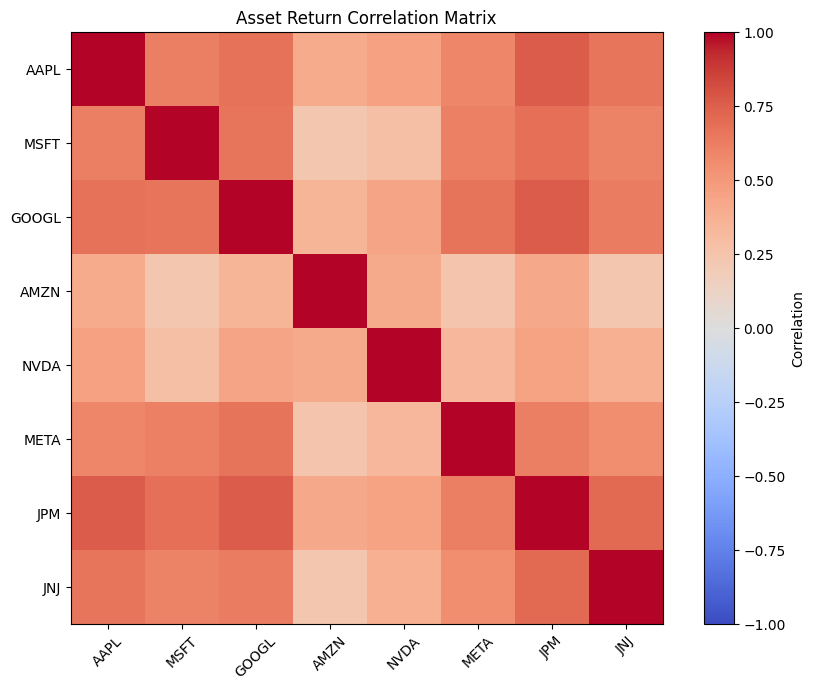

In [21]:
# ---------------------------------------------------------
# Visualize correlations
# ---------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(tickers)),
    tickers,
    rotation=45
)

plt.yticks(
    range(len(tickers)),
    tickers
)

plt.title("Asset Return Correlation Matrix")
plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------
# Daily covariance matrix
# ---------------------------------------------------------

daily_covariance = returns.cov()

daily_covariance.round(6)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Ticker,,,,,,,,
AAPL,0.000412,0.000279,0.000275,0.000103,0.000186,0.000330,0.000296,0.000435
AMZN,0.000279,0.000492,0.000293,0.000063,0.000125,0.000374,0.000291,0.000436
GOOGL,0.000275,0.000293,0.000402,0.000087,0.000177,0.000370,0.000292,0.000411
JNJ,0.000103,0.000063,0.000087,0.000157,0.000104,0.000084,0.000100,0.000095
JPM,0.000186,0.000125,0.000177,0.000104,0.000404,0.000183,0.000174,0.000246
META,0.000330,0.000374,0.000370,0.000084,0.000183,0.000755,0.000327,0.000495
MSFT,0.000296,0.000291,0.000292,0.000100,0.000174,0.000327,0.000369,0.000443
NVDA,0.000435,0.000436,0.000411,0.000095,0.000246,0.000495,0.000443,0.001064


In [23]:
# ---------------------------------------------------------
# Annualized covariance matrix
# ---------------------------------------------------------
# Covariance scales approximately with the number of
# observations in a year.

annual_covariance = daily_covariance * 252

annual_covariance.round(4)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA
Ticker,,,,,,,,
AAPL,0.1039,0.0703,0.0692,0.0260,0.0468,0.0833,0.0746,0.1097
AMZN,0.0703,0.1241,0.0739,0.0160,0.0316,0.0943,0.0733,0.1099
GOOGL,0.0692,0.0739,0.1012,0.0219,0.0445,0.0931,0.0736,0.1035
JNJ,0.0260,0.0160,0.0219,0.0395,0.0262,0.0211,0.0253,0.0240
JPM,0.0468,0.0316,0.0445,0.0262,0.1017,0.0460,0.0438,0.0621
META,0.0833,0.0943,0.0931,0.0211,0.0460,0.1904,0.0825,0.1246
MSFT,0.0746,0.0733,0.0736,0.0253,0.0438,0.0825,0.0930,0.1116
NVDA,0.1097,0.1099,0.1035,0.0240,0.0621,0.1246,0.1116,0.2680


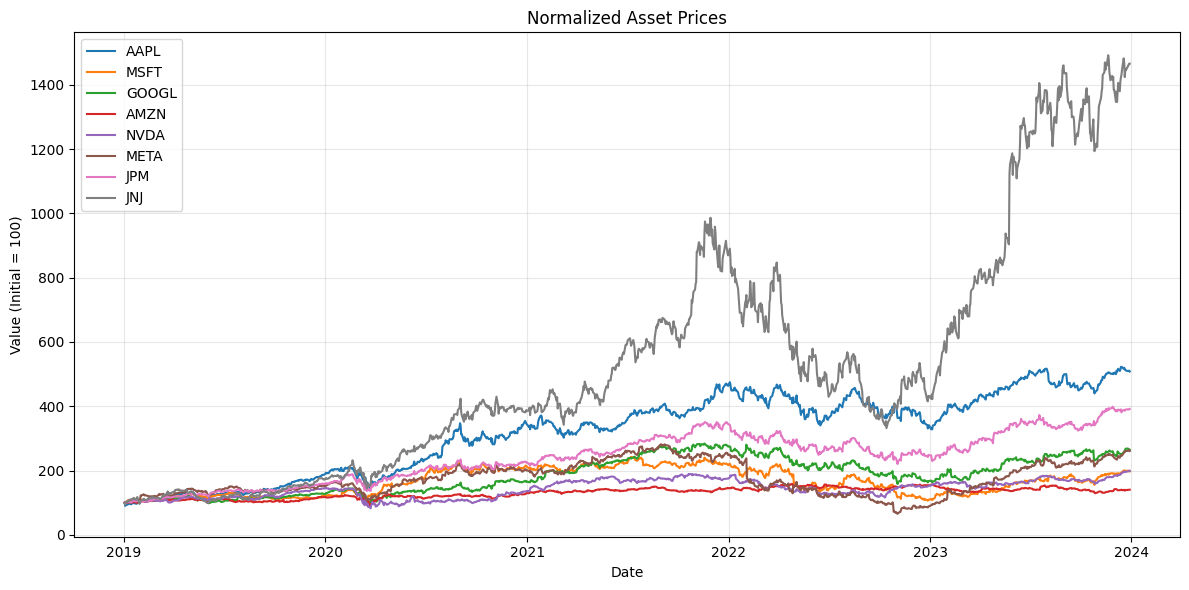

In [24]:
# ---------------------------------------------------------
# Normalize prices to 100 to compare relative performance
# ---------------------------------------------------------

normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 6))

plt.plot(normalized_prices)

plt.title("Normalized Asset Prices")
plt.xlabel("Date")
plt.ylabel("Value (Initial = 100)")
plt.legend(tickers)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

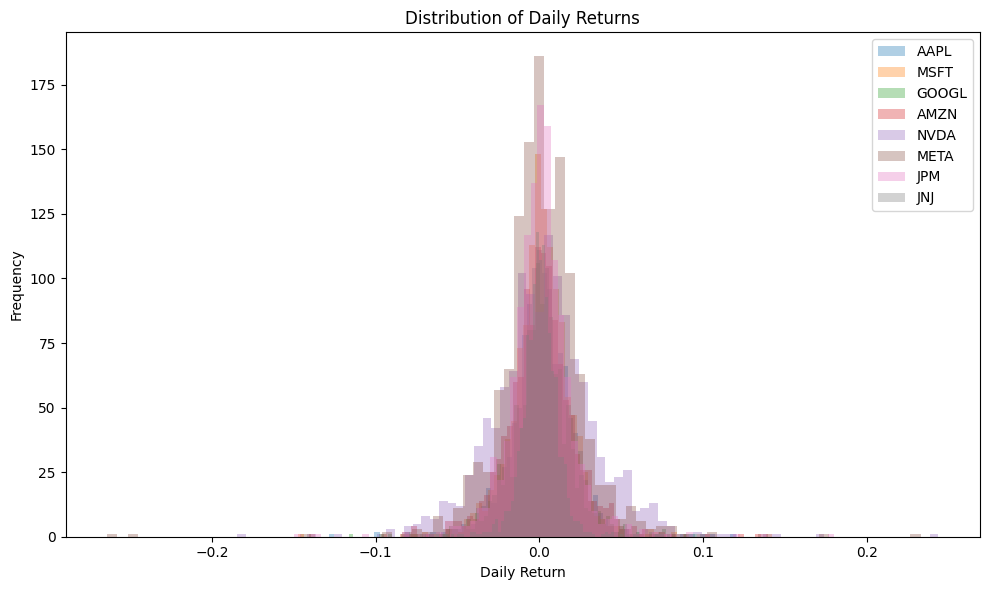

In [25]:
# ---------------------------------------------------------
# Distribution of daily returns
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

for ticker in tickers:
    plt.hist(
        returns[ticker],
        bins=80,
        alpha=0.35,
        label=ticker
    )

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# ---------------------------------------------------------
# Inputs for portfolio optimization
# ---------------------------------------------------------

mu = annual_return.values
Sigma = annual_covariance.values

print("Expected return vector shape:", mu.shape)
print("Covariance matrix shape:", Sigma.shape)

Expected return vector shape: (8,)
Covariance matrix shape: (8, 8)


In [27]:
# ---------------------------------------------------------
# Create an equal-weight portfolio
# ---------------------------------------------------------

n_assets = len(tickers)

# Allocate equal weight to every asset
equal_weights = np.ones(n_assets) / n_assets

print("Number of assets:", n_assets)
print("Weights:", equal_weights)
print("Sum of weights:", equal_weights.sum())

Number of assets: 8
Weights: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
Sum of weights: 1.0


In [28]:
# Create a readable table of portfolio weights

equal_weight_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": equal_weights
})

equal_weight_df

,Asset,Weight
0,AAPL,0.125
1,MSFT,0.125
2,GOOGL,0.125
3,AMZN,0.125
4,NVDA,0.125
5,META,0.125
6,JPM,0.125
7,JNJ,0.125


In [29]:
equal_weight_df["Weight (%)"] = equal_weight_df["Weight"] * 100

equal_weight_df

,Asset,Weight,Weight (%)
0,AAPL,0.125,12.5
1,MSFT,0.125,12.5
2,GOOGL,0.125,12.5
3,AMZN,0.125,12.5
4,NVDA,0.125,12.5
5,META,0.125,12.5
6,JPM,0.125,12.5
7,JNJ,0.125,12.5


In [30]:
# ---------------------------------------------------------
# Calculate expected annual portfolio return
# ---------------------------------------------------------

equal_expected_return = equal_weights @ mu

print(
    f"Expected annual return: "
    f"{equal_expected_return:.2%}"
)

Expected annual return: 29.76%


In [31]:
# ---------------------------------------------------------
# Calculate portfolio variance
# ---------------------------------------------------------

equal_variance = (
    equal_weights.T
    @ Sigma
    @ equal_weights
)

print(
    f"Portfolio variance: "
    f"{equal_variance:.6f}"
)

Portfolio variance: 0.071672


In [32]:
# ---------------------------------------------------------
# Calculate annualized portfolio volatility
# ---------------------------------------------------------

equal_volatility = np.sqrt(equal_variance)

print(
    f"Portfolio volatility: "
    f"{equal_volatility:.2%}"
)

Portfolio volatility: 26.77%


In [33]:
# ---------------------------------------------------------
# Calculate Sharpe ratio
# ---------------------------------------------------------

risk_free_rate = 0.0

equal_sharpe = (
    (equal_expected_return - risk_free_rate)
    / equal_volatility
)

print(
    f"Sharpe ratio: "
    f"{equal_sharpe:.3f}"
)

Sharpe ratio: 1.111


In [34]:
# ---------------------------------------------------------
# Calculate historical daily portfolio returns
# ---------------------------------------------------------

equal_portfolio_returns = returns @ equal_weights

equal_portfolio_returns.head()

,0
Date,
2019-01-03,-0.038611
2019-01-04,0.044426
2019-01-07,0.009919
2019-01-08,0.010076
2019-01-09,0.006443


In [35]:
# ---------------------------------------------------------
# Calculate cumulative portfolio value
# ---------------------------------------------------------

equal_portfolio_value = (
    100 * (1 + equal_portfolio_returns).cumprod()
)

equal_portfolio_value.head()

,0
Date,
2019-01-03,96.138871
2019-01-04,100.409966
2019-01-07,101.405973
2019-01-08,102.427722
2019-01-09,103.087697


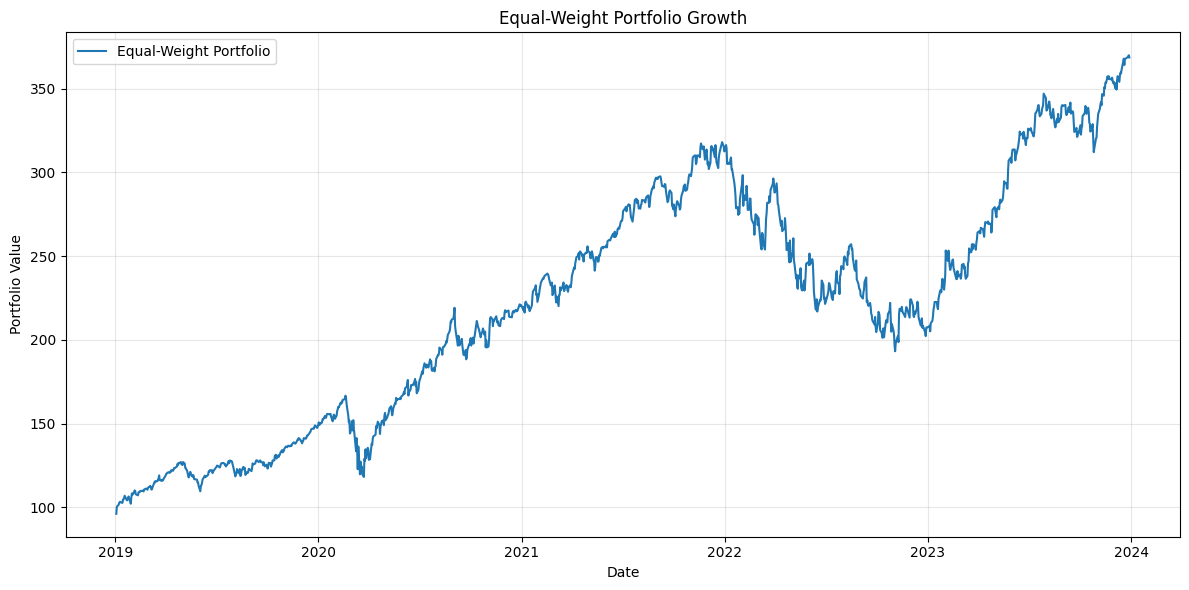

In [36]:
# ---------------------------------------------------------
# Plot equal-weight portfolio growth
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    equal_portfolio_value,
    label="Equal-Weight Portfolio"
)

plt.title("Equal-Weight Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# ---------------------------------------------------------
# Historical portfolio performance
# ---------------------------------------------------------

historical_return = (
    (1 + equal_portfolio_returns).prod()
    ** (252 / len(equal_portfolio_returns))
    - 1
)

historical_volatility = (
    equal_portfolio_returns.std() * np.sqrt(252)
)

historical_sharpe = (
    historical_return / historical_volatility
)

print(f"Annualized historical return: {historical_return:.2%}")
print(f"Annualized volatility: {historical_volatility:.2%}")
print(f"Sharpe ratio: {historical_sharpe:.3f}")

Annualized historical return: 29.89%
Annualized volatility: 26.77%
Sharpe ratio: 1.117


In [38]:
# ---------------------------------------------------------
# Calculate maximum drawdown
# ---------------------------------------------------------

running_max = equal_portfolio_value.cummax()

drawdown = (
    equal_portfolio_value / running_max
) - 1

max_drawdown = drawdown.min()

print(
    f"Maximum drawdown: "
    f"{max_drawdown:.2%}"
)

Maximum drawdown: -39.26%


In [39]:
# ---------------------------------------------------------
# Equal-weight portfolio summary
# ---------------------------------------------------------

equal_weight_summary = pd.Series({
    "Expected Return": equal_expected_return,
    "Expected Volatility": equal_volatility,
    "Expected Sharpe": equal_sharpe,
    "Historical Return": historical_return,
    "Historical Volatility": historical_volatility,
    "Historical Sharpe": historical_sharpe,
    "Maximum Drawdown": max_drawdown
})

equal_weight_summary

,0
Expected Return,0.297552
Expected Volatility,0.267716
Expected Sharpe,1.111447
Historical Return,0.298911
Historical Volatility,0.267716
Historical Sharpe,1.116522
Maximum Drawdown,-0.392570


In [40]:
# ---------------------------------------------------------
# Import optimization function
# ---------------------------------------------------------

from scipy.optimize import minimize

In [41]:
# ---------------------------------------------------------
# Portfolio variance objective function
# ---------------------------------------------------------

def portfolio_variance(weights, covariance_matrix):
    """
    Calculate portfolio variance.

    Parameters
    ----------
    weights : numpy array
        Portfolio weights.

    covariance_matrix : numpy array
        Annualized covariance matrix.

    Returns
    -------
    float
        Portfolio variance.
    """

    return weights.T @ covariance_matrix @ weights

In [42]:
# Test the objective function using equal weights

test_variance = portfolio_variance(
    equal_weights,
    Sigma
)

print(f"Equal-weight variance: {test_variance:.6f}")

Equal-weight variance: 0.071672


In [43]:
# ---------------------------------------------------------
# Fully-invested constraint
# ---------------------------------------------------------

def weight_sum_constraint(weights):
    return np.sum(weights) - 1

In [44]:
# ---------------------------------------------------------
# Long-only bounds
# ---------------------------------------------------------
# Each asset weight must lie between 0 and 1.

bounds = [(0, 1) for _ in range(n_assets)]

In [45]:
# ---------------------------------------------------------
# Initial guess
# ---------------------------------------------------------

initial_weights = equal_weights.copy()

print(initial_weights)

[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


In [46]:
# ---------------------------------------------------------
# Minimum Variance Portfolio optimization
# ---------------------------------------------------------

optimization_result = minimize(
    fun=portfolio_variance,
    x0=initial_weights,
    args=(Sigma,),
    method="SLSQP",
    bounds=bounds,
    constraints={
        "type": "eq",
        "fun": weight_sum_constraint
    }
)

In [47]:
# ---------------------------------------------------------
# Check optimization status
# ---------------------------------------------------------

print("Optimization successful:", optimization_result.success)
print("Message:", optimization_result.message)

Optimization successful: True
Message: Optimization terminated successfully


In [48]:
# ---------------------------------------------------------
# Extract optimized portfolio weights
# ---------------------------------------------------------

min_variance_weights = optimization_result.x

print(min_variance_weights)
print("Sum of weights:", min_variance_weights.sum())

[8.60608473e-18 1.37348728e-01 3.98219586e-02 7.35065239e-01
 8.77640738e-02 1.01787442e-18 0.00000000e+00 0.00000000e+00]
Sum of weights: 0.9999999999999999


In [49]:
# ---------------------------------------------------------
# Compare Equal Weight vs Minimum Variance weights
# ---------------------------------------------------------

weight_comparison = pd.DataFrame({
    "Asset": tickers,
    "Equal Weight (%)": equal_weights * 100,
    "Min Variance (%)": min_variance_weights * 100
})

weight_comparison

,Asset,Equal Weight (%),Min Variance (%)
0,AAPL,12.5,8.606085e-16
1,MSFT,12.5,1.373487e+01
2,GOOGL,12.5,3.982196e+00
3,AMZN,12.5,7.350652e+01
4,NVDA,12.5,8.776407e+00
5,META,12.5,1.017874e-16
6,JPM,12.5,0.000000e+00
7,JNJ,12.5,0.000000e+00


In [50]:
print(
    "Weight sum:",
    min_variance_weights.sum()
)

Weight sum: 0.9999999999999999


In [51]:
# ---------------------------------------------------------
# Minimum variance portfolio statistics
# ---------------------------------------------------------

min_variance = portfolio_variance(
    min_variance_weights,
    Sigma
)

print(
    f"Minimum variance: {min_variance:.6f}"
)

Minimum variance: 0.034368


In [52]:
min_volatility = np.sqrt(min_variance)

print(
    f"Minimum variance portfolio volatility: "
    f"{min_volatility:.2%}"
)

Minimum variance portfolio volatility: 18.54%


In [53]:
# ---------------------------------------------------------
# Expected return of minimum variance portfolio
# ---------------------------------------------------------

min_variance_return = (
    min_variance_weights @ mu
)

print(
    f"Expected annual return: "
    f"{min_variance_return:.2%}"
)

Expected annual return: 11.82%


In [54]:
# ---------------------------------------------------------
# Sharpe ratio of minimum variance portfolio
# ---------------------------------------------------------

min_variance_sharpe = (
    min_variance_return / min_volatility
)

print(
    f"Sharpe ratio: "
    f"{min_variance_sharpe:.3f}"
)

Sharpe ratio: 0.638


In [55]:
# ---------------------------------------------------------
# Compare portfolio statistics
# ---------------------------------------------------------

portfolio_comparison = pd.DataFrame({
    "Equal Weight": [
        equal_expected_return,
        equal_volatility,
        equal_sharpe
    ],

    "Minimum Variance": [
        min_variance_return,
        min_volatility,
        min_variance_sharpe
    ]
}, index=[
    "Expected Return",
    "Volatility",
    "Sharpe Ratio"
])

portfolio_comparison

,Equal Weight,Minimum Variance
Expected Return,0.297552,0.118188
Volatility,0.267716,0.185385
Sharpe Ratio,1.111447,0.637528


In [56]:
# ---------------------------------------------------------
# Historical daily returns of minimum variance portfolio
# ---------------------------------------------------------

min_variance_portfolio_returns = (
    returns @ min_variance_weights
)

min_variance_portfolio_returns.head()

,0
Date,
2019-01-03,-0.017498
2019-01-04,0.024491
2019-01-07,-0.000015
2019-01-08,0.019539
2019-01-09,-0.005875


In [57]:
# ---------------------------------------------------------
# Portfolio value starting from 100
# ---------------------------------------------------------

min_variance_portfolio_value = (
    100 * (1 + min_variance_portfolio_returns).cumprod()
)

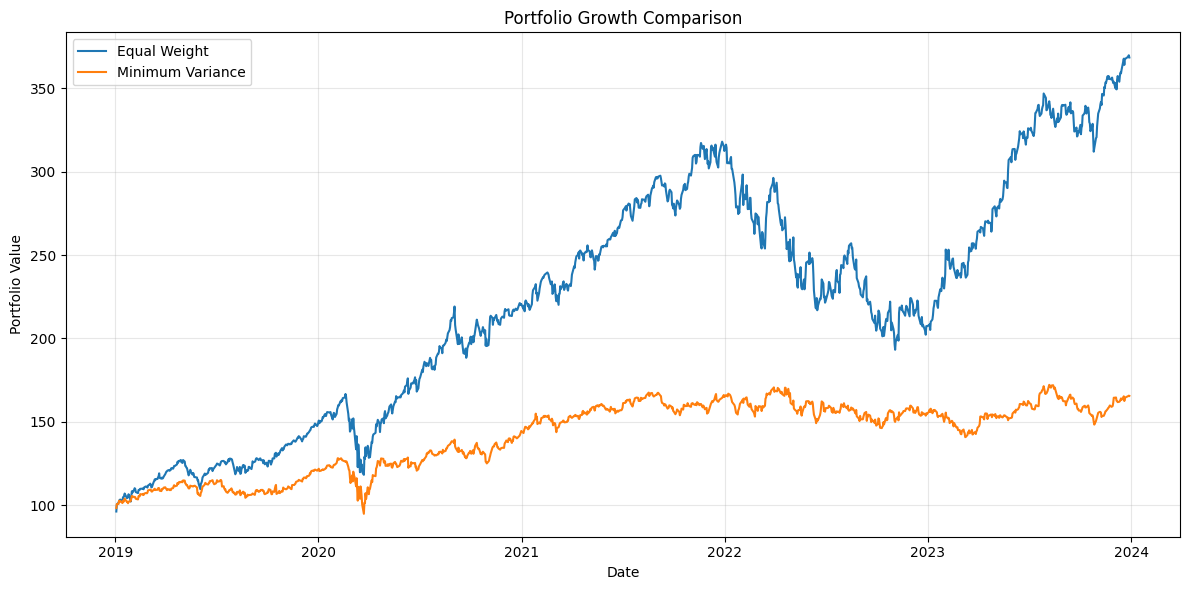

In [58]:
# ---------------------------------------------------------
# Compare Equal Weight and Minimum Variance portfolios
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    equal_portfolio_value,
    label="Equal Weight"
)

plt.plot(
    min_variance_portfolio_value,
    label="Minimum Variance"
)

plt.title("Portfolio Growth Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# ---------------------------------------------------------
# Maximum drawdown of Minimum Variance portfolio
# ---------------------------------------------------------

min_variance_running_max = (
    min_variance_portfolio_value.cummax()
)

min_variance_drawdown = (
    min_variance_portfolio_value
    / min_variance_running_max
) - 1

min_variance_max_drawdown = (
    min_variance_drawdown.min()
)

print(
    f"Maximum drawdown: "
    f"{min_variance_max_drawdown:.2%}"
)

Maximum drawdown: -26.03%


In [60]:
# ---------------------------------------------------------
# Final portfolio comparison
# ---------------------------------------------------------

final_comparison = pd.DataFrame({

    "Equal Weight": {
        "Expected Return": equal_expected_return,
        "Volatility": equal_volatility,
        "Sharpe Ratio": equal_sharpe,
        "Max Drawdown": max_drawdown
    },

    "Minimum Variance": {
        "Expected Return": min_variance_return,
        "Volatility": min_volatility,
        "Sharpe Ratio": min_variance_sharpe,
        "Max Drawdown": min_variance_max_drawdown
    }
})

final_comparison

,Equal Weight,Minimum Variance
Expected Return,0.297552,0.118188
Volatility,0.267716,0.185385
Sharpe Ratio,1.111447,0.637528
Max Drawdown,-0.392570,-0.260270


In [61]:
# Format each metric appropriately

formatted_comparison = final_comparison.copy()

for metric in [
    "Expected Return",
    "Volatility",
    "Max Drawdown"
]:
    formatted_comparison.loc[metric] = (
        formatted_comparison.loc[metric] * 100
    )

formatted_comparison

,Equal Weight,Minimum Variance
Expected Return,29.755234,11.818841
Volatility,26.771615,18.538539
Sharpe Ratio,1.111447,0.637528
Max Drawdown,-39.257013,-26.026954


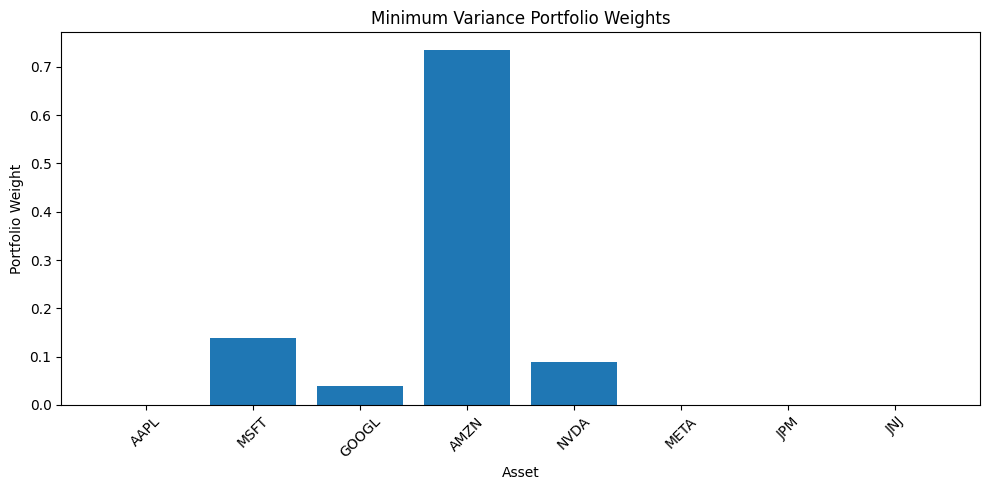

In [62]:
# ---------------------------------------------------------
# Plot optimized portfolio weights
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    tickers,
    min_variance_weights
)

plt.title("Minimum Variance Portfolio Weights")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Efficient Frontier
1. What are we trying to find?

The minimum-variance portfolio only answers:

"What is the lowest-risk portfolio?"

But an investor may say:

"I want at least 10% expected return. What is the lowest risk I can achieve?"

In [63]:
# ---------------------------------------------------------
# Efficient Frontier: target return constraint
# ---------------------------------------------------------

def target_return_constraint(weights, expected_returns, target_return):
    """
    Constraint ensuring that the portfolio achieves
    the specified target expected return.
    """

    return weights @ expected_returns - target_return

In [64]:
# ---------------------------------------------------------
# Define target returns
# ---------------------------------------------------------

min_target = mu.min()
max_target = mu.max()

target_returns = np.linspace(
    min_target,
    max_target,
    30
)

print("Minimum target:", min_target)
print("Maximum target:", max_target)

Minimum target: 0.08782863941897422
Maximum target: 0.6718259529774193


In [65]:
# ---------------------------------------------------------
# Generate Efficient Frontier
# ---------------------------------------------------------

frontier_returns = []
frontier_volatility = []
frontier_weights = []

for target in target_returns:

    constraints = [
        {
            "type": "eq",
            "fun": weight_sum_constraint
        },
        {
            "type": "eq",
            "fun": target_return_constraint,
            "args": (mu, target)
        }
    ]

    result = minimize(
        fun=portfolio_variance,
        x0=equal_weights,
        args=(Sigma,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    # Only store successful optimization results
    if result.success:

        weights = result.x

        variance = portfolio_variance(
            weights,
            Sigma
        )

        volatility = np.sqrt(variance)

        frontier_returns.append(
            weights @ mu
        )

        frontier_volatility.append(
            volatility
        )

        frontier_weights.append(
            weights
        )

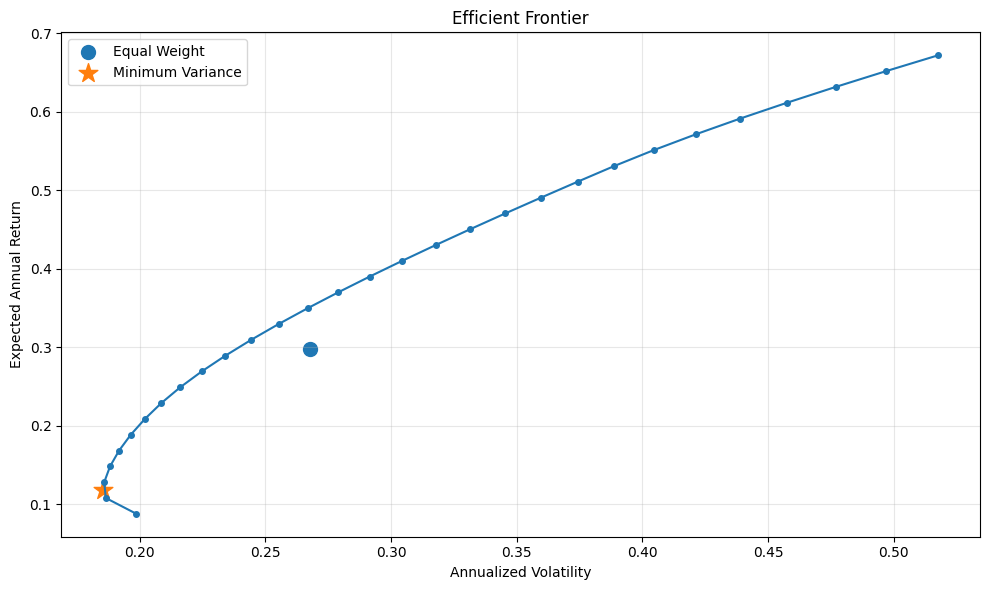

In [66]:
# ---------------------------------------------------------
# Plot Efficient Frontier
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    frontier_volatility,
    frontier_returns,
    marker="o",
    markersize=4
)

plt.scatter(
    equal_volatility,
    equal_expected_return,
    marker="o",
    s=100,
    label="Equal Weight"
)

plt.scatter(
    min_volatility,
    min_variance_return,
    marker="*",
    s=200,
    label="Minimum Variance"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mean variance opti

In [67]:
# ---------------------------------------------------------
# Mean-Variance Optimization objective
# ---------------------------------------------------------

def mean_variance_objective(
    weights,
    expected_returns,
    covariance_matrix,
    risk_aversion
):
    """
    MVO objective in minimization form:

        lambda * variance - expected return
    """

    expected_return = weights @ expected_returns

    variance = (
        weights.T
        @ covariance_matrix
        @ weights
    )

    return (
        risk_aversion * variance
        - expected_return
    )

In [68]:
# ---------------------------------------------------------
# Risk-aversion values
# ---------------------------------------------------------

risk_aversion_values = [
    0.1,
    1,
    5,
    10
]

In [70]:
# ---------------------------------------------------------
# Run Mean-Variance Optimization
# ---------------------------------------------------------

mvo_results = {}

for risk_aversion in risk_aversion_values:

    result = minimize(
        fun=mean_variance_objective,
        x0=equal_weights,
        args=(
            mu,
            Sigma,
            risk_aversion
        ),
        method="SLSQP",
        bounds=bounds,
        constraints={
            "type": "eq",
            "fun": weight_sum_constraint
        }
    )

    if result.success:
        weights = result.x

        expected_return = weights @ mu

        variance = portfolio_variance(
            weights,
            Sigma
        )

        volatility = np.sqrt(variance)

        sharpe = expected_return / volatility

        mvo_results[risk_aversion] = {
            "weights": weights,
            "return": expected_return,
            "volatility": volatility,
            "sharpe": sharpe
        }

In [71]:
# ---------------------------------------------------------
# Compare MVO portfolios
# ---------------------------------------------------------

mvo_summary = []

for risk_aversion, result in mvo_results.items():

    mvo_summary.append({
        "Risk Aversion": risk_aversion,
        "Expected Return": result["return"],
        "Volatility": result["volatility"],
        "Sharpe Ratio": result["sharpe"]
    })

mvo_summary = pd.DataFrame(mvo_summary)

mvo_summary

,Risk Aversion,Expected Return,Volatility,Sharpe Ratio
0,0.1,0.671826,0.517699,1.297714
1,1.0,0.649910,0.495226,1.312350
2,5.0,0.268364,0.224305,1.196421
3,10.0,0.188348,0.196362,0.959186


In [72]:
mvo_summary.style.format({
    "Expected Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
})

,Risk Aversion,Expected Return,Volatility,Sharpe Ratio
0,0.100000,67.18%,51.77%,1.298
1,1.000000,64.99%,49.52%,1.312
2,5.000000,26.84%,22.43%,1.196
3,10.000000,18.83%,19.64%,0.959


In [73]:
mvo_summary.style.format({
    "Expected Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
})

,Risk Aversion,Expected Return,Volatility,Sharpe Ratio
0,0.100000,67.18%,51.77%,1.298
1,1.000000,64.99%,49.52%,1.312
2,5.000000,26.84%,22.43%,1.196
3,10.000000,18.83%,19.64%,0.959


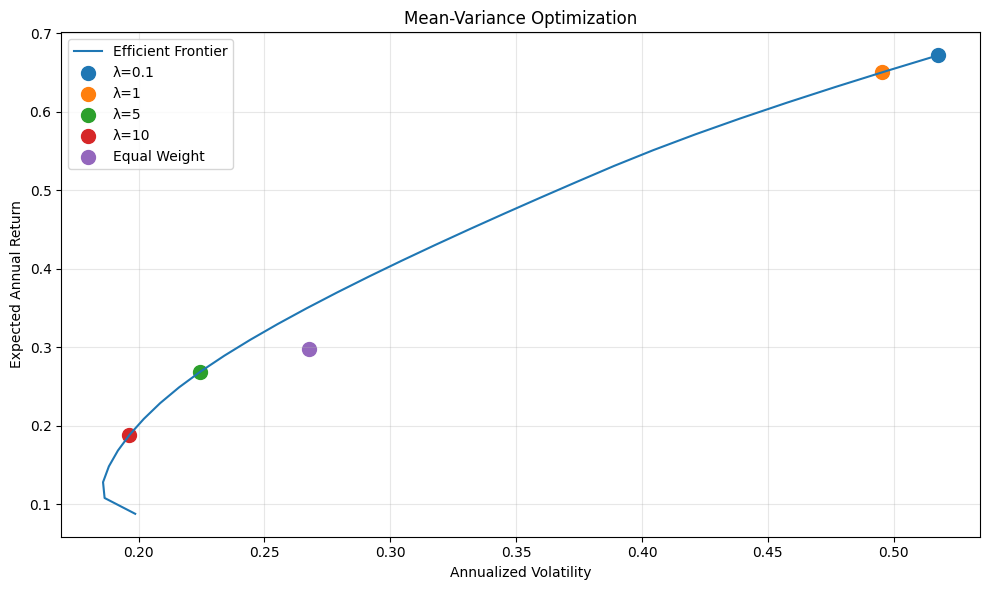

In [74]:
# ---------------------------------------------------------
# Plot Efficient Frontier + MVO portfolios
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    frontier_volatility,
    frontier_returns,
    label="Efficient Frontier"
)

for risk_aversion, result in mvo_results.items():

    plt.scatter(
        result["volatility"],
        result["return"],
        s=100,
        label=f"λ={risk_aversion}"
    )

plt.scatter(
    equal_volatility,
    equal_expected_return,
    s=100,
    label="Equal Weight"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Mean-Variance Optimization")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Monte carlo experiments

In [75]:
# ---------------------------------------------------------
# Basic Monte Carlo simulation
# ---------------------------------------------------------

rng = np.random.default_rng(42)

simulation_sizes = [
    100,
    1_000,
    10_000,
    100_000
]

for n in simulation_sizes:

    samples = rng.normal(
        loc=0,
        scale=1,
        size=n
    )

    print(
        f"n={n:>6} | "
        f"mean={samples.mean():.4f} | "
        f"std={samples.std():.4f}"
    )

n=   100 | mean=-0.0503 | std=0.7728
n=  1000 | mean=-0.0186 | std=1.0004
n= 10000 | mean=-0.0069 | std=1.0090
n=100000 | mean=-0.0040 | std=1.0033


In [76]:
# ---------------------------------------------------------
# Simulate multivariate asset returns
# ---------------------------------------------------------

n_simulations = 10_000

simulated_returns = rng.multivariate_normal(
    mean=mu,
    cov=Sigma,
    size=n_simulations
)

print(
    "Simulation shape:",
    simulated_returns.shape
)

Simulation shape: (10000, 8)


In [79]:
# ---------------------------------------------------------
# Simulated returns for MVO portfolio
# ---------------------------------------------------------

mvo_weights = mvo_results[1]["weights"]

simulated_portfolio_returns = (
    simulated_returns @ mvo_weights
)

print(
    "Simulated portfolio return shape:",
    simulated_portfolio_returns.shape
)

Simulated portfolio return shape: (10000,)


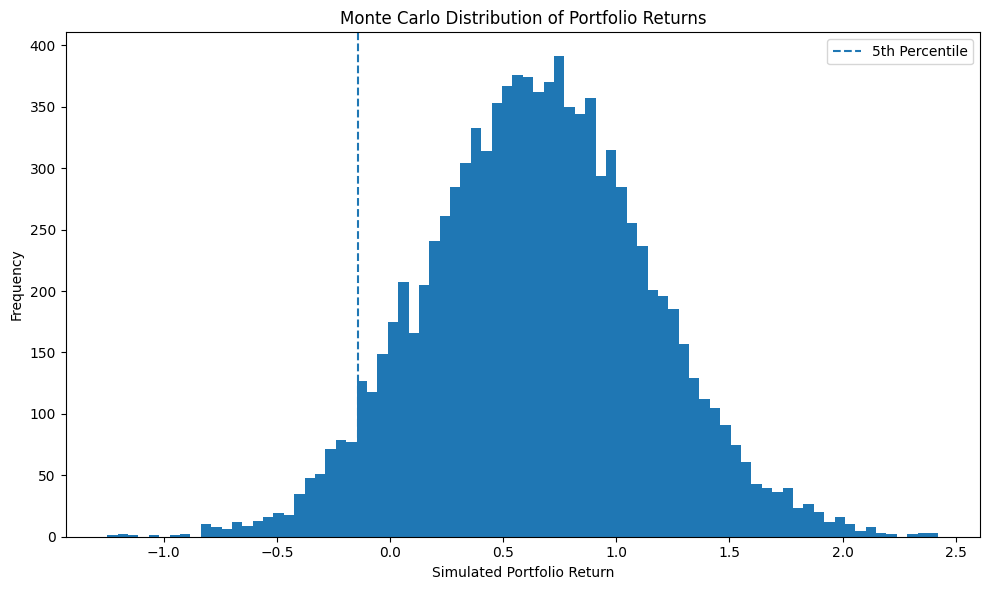

In [80]:
# ---------------------------------------------------------
# Distribution of simulated portfolio returns
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    simulated_portfolio_returns,
    bins=80
)

plt.axvline(
    np.percentile(
        simulated_portfolio_returns,
        5
    ),
    linestyle="--",
    label="5th Percentile"
)

plt.xlabel("Simulated Portfolio Return")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of Portfolio Returns")
plt.legend()

plt.tight_layout()
plt.show()

In [82]:
# ---------------------------------------------------------
# Monte Carlo risk statistics
# ---------------------------------------------------------

mc_mean = simulated_portfolio_returns.mean()

mc_std = simulated_portfolio_returns.std()

mc_5th_percentile = np.percentile(
    simulated_portfolio_returns,
    5
)

mc_95th_percentile = np.percentile(
    simulated_portfolio_returns,
    95
)

prob_negative = np.mean(
    simulated_portfolio_returns < 0
)

print(f"Mean simulated return: {mc_mean:.2%}")
print(f"Simulated volatility: {mc_std:.2%}")
print(f"5th percentile: {mc_5th_percentile:.2%}")
print(f"95th percentile: {mc_95th_percentile:.2%}")
print(f"Probability of negative return: {prob_negative:.2%}")

Mean simulated return: 65.59%
Simulated volatility: 49.19%
5th percentile: -14.00%
95th percentile: 147.09%
Probability of negative return: 9.02%


In [83]:
# ---------------------------------------------------------
# Train / Test split
# ---------------------------------------------------------
# 2019-2022: used for estimating portfolio parameters
# 2023:     used only for out-of-sample evaluation

train_returns = returns.loc["2019-01-01":"2022-12-31"]

test_returns = returns.loc["2023-01-01":"2023-12-31"]

print("Training period:")
print(train_returns.index.min(), "to", train_returns.index.max())

print("\nTest period:")
print(test_returns.index.min(), "to", test_returns.index.max())

print("\nTrain shape:", train_returns.shape)
print("Test shape:", test_returns.shape)

Training period:
2019-01-03 00:00:00 to 2022-12-30 00:00:00

Test period:
2023-01-03 00:00:00 to 2023-12-29 00:00:00

Train shape: (1007, 8)
Test shape: (250, 8)


In [84]:
# ---------------------------------------------------------
# Estimate parameters using training data only
# ---------------------------------------------------------

train_daily_mean = train_returns.mean()
train_daily_covariance = train_returns.cov()

# Annualize
train_mu = (train_daily_mean * 252).values

train_Sigma = (
    train_daily_covariance * 252
).values

print("Expected return vector shape:", train_mu.shape)
print("Covariance matrix shape:", train_Sigma.shape)

Expected return vector shape: (8,)
Covariance matrix shape: (8, 8)


In [85]:
# ---------------------------------------------------------
# Equal-weight portfolio
# ---------------------------------------------------------

equal_weights = np.ones(n_assets) / n_assets

In [86]:
# ---------------------------------------------------------
# Minimum Variance Portfolio
# ---------------------------------------------------------

min_var_result = minimize(
    fun=portfolio_variance,
    x0=equal_weights,
    args=(train_Sigma,),
    method="SLSQP",
    bounds=bounds,
    constraints={
        "type": "eq",
        "fun": weight_sum_constraint
    }
)

if not min_var_result.success:
    raise ValueError(
        f"Minimum variance optimization failed: "
        f"{min_var_result.message}"
    )

min_var_weights = min_var_result.x

In [87]:
# ---------------------------------------------------------
# Mean-Variance Portfolio
# ---------------------------------------------------------

risk_aversion = 1.0

mvo_result = minimize(
    fun=mean_variance_objective,
    x0=equal_weights,
    args=(
        train_mu,
        train_Sigma,
        risk_aversion
    ),
    method="SLSQP",
    bounds=bounds,
    constraints={
        "type": "eq",
        "fun": weight_sum_constraint
    }
)

if not mvo_result.success:
    raise ValueError(
        f"MVO optimization failed: "
        f"{mvo_result.message}"
    )

mvo_weights = mvo_result.x

In [88]:
# ---------------------------------------------------------
# Compare portfolio allocations
# ---------------------------------------------------------

weights_df = pd.DataFrame({
    "Asset": tickers,
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "MVO": mvo_weights
})

weights_df

,Asset,Equal Weight,Minimum Variance,MVO
0,AAPL,0.125,1.357843e-17,5.653879e-01
1,MSFT,0.125,1.404748e-01,0.000000e+00
2,GOOGL,0.125,3.410821e-02,0.000000e+00
3,AMZN,0.125,7.628959e-01,9.432559e-18
4,NVDA,0.125,6.252106e-02,0.000000e+00
5,META,0.125,0.000000e+00,1.266348e-16
6,JPM,0.125,0.000000e+00,1.318390e-16
7,JNJ,0.125,0.000000e+00,4.346121e-01


In [89]:
weights_df_percent = weights_df.copy()

for column in [
    "Equal Weight",
    "Minimum Variance",
    "MVO"
]:
    weights_df_percent[column] *= 100

weights_df_percent

,Asset,Equal Weight,Minimum Variance,MVO
0,AAPL,12.5,1.357843e-15,5.653879e+01
1,MSFT,12.5,1.404748e+01,0.000000e+00
2,GOOGL,12.5,3.410821e+00,0.000000e+00
3,AMZN,12.5,7.628959e+01,9.432559e-16
4,NVDA,12.5,6.252106e+00,0.000000e+00
5,META,12.5,0.000000e+00,1.266348e-14
6,JPM,12.5,0.000000e+00,1.318390e-14
7,JNJ,12.5,0.000000e+00,4.346121e+01


In [90]:
# ---------------------------------------------------------
# Calculate out-of-sample portfolio returns
# ---------------------------------------------------------

test_portfolio_returns = pd.DataFrame(index=test_returns.index)

test_portfolio_returns["Equal Weight"] = (
    test_returns @ equal_weights
)

test_portfolio_returns["Minimum Variance"] = (
    test_returns @ min_var_weights
)

test_portfolio_returns["MVO"] = (
    test_returns @ mvo_weights
)

test_portfolio_returns.head()

,Equal Weight,Minimum Variance,MVO
Date,,,
2023-01-03,0.003222,0.010514,-0.030040
2023-01-04,0.002324,0.007378,0.019008
2023-01-05,-0.016139,-0.009708,-0.020258
2023-01-06,0.023821,0.012837,0.038900
2023-01-09,0.006745,-0.017670,0.024804


In [91]:
# ---------------------------------------------------------
# Portfolio performance metrics
# ---------------------------------------------------------

def calculate_performance(portfolio_returns):
    """
    Calculate out-of-sample portfolio performance metrics.
    """

    # Annualized return
    annual_return = (
        (1 + portfolio_returns).prod()
        ** (252 / len(portfolio_returns))
        - 1
    )

    # Annualized volatility
    annual_volatility = (
        portfolio_returns.std() * np.sqrt(252)
    )

    # Sharpe ratio, assuming zero risk-free rate
    sharpe = (
        annual_return / annual_volatility
    )

    # Portfolio value starting at 100
    portfolio_value = (
        100 * (1 + portfolio_returns).cumprod()
    )

    # Running maximum
    running_max = portfolio_value.cummax()

    # Drawdown
    drawdown = (
        portfolio_value / running_max
    ) - 1

    # Maximum drawdown
    max_drawdown = drawdown.min()

    return {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown
    }

In [92]:
# ---------------------------------------------------------
# Calculate performance of all portfolios
# ---------------------------------------------------------

performance_results = {}

for portfolio in test_portfolio_returns.columns:

    performance_results[portfolio] = (
        calculate_performance(
            test_portfolio_returns[portfolio]
        )
    )

performance_df = pd.DataFrame(
    performance_results
).T

performance_df

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Equal Weight,0.786255,0.198526,3.960457,-0.100642
Minimum Variance,0.060252,0.142293,0.423438,-0.139560
MVO,1.189586,0.281129,4.231464,-0.141989


In [93]:
performance_df.style.format({
    "Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Maximum Drawdown": "{:.2%}"
})

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Equal Weight,78.63%,19.85%,3.960,-10.06%
Minimum Variance,6.03%,14.23%,0.423,-13.96%
MVO,118.96%,28.11%,4.231,-14.20%


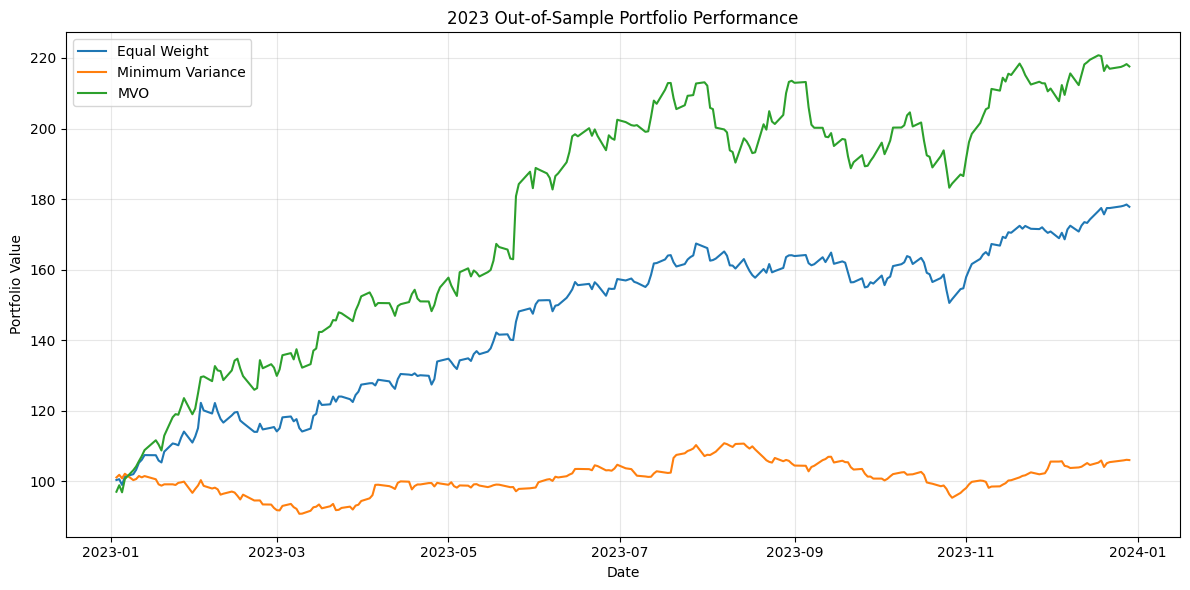

In [95]:
# ---------------------------------------------------------
# Plot out-of-sample portfolio growth
# ---------------------------------------------------------

test_portfolio_value = (
    100 * (1 + test_portfolio_returns).cumprod()
)

plt.figure(figsize=(12, 6))

for portfolio in test_portfolio_value.columns:

    plt.plot(
        test_portfolio_value[portfolio],
        label=portfolio
    )

plt.title("2023 Out-of-Sample Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [96]:
# ---------------------------------------------------------
# Monte Carlo simulation
# ---------------------------------------------------------

n_simulations = 10_000

rng = np.random.default_rng(42)

simulated_asset_returns = rng.multivariate_normal(
    mean=train_mu / 252,
    cov=train_Sigma / 252,
    size=n_simulations
)

print(
    "Simulation shape:",
    simulated_asset_returns.shape
)

Simulation shape: (10000, 8)


In [97]:
# ---------------------------------------------------------
# Simulated portfolio returns
# ---------------------------------------------------------

simulated_portfolio_returns = pd.DataFrame({

    "Equal Weight":
        simulated_asset_returns @ equal_weights,

    "Minimum Variance":
        simulated_asset_returns @ min_var_weights,

    "MVO":
        simulated_asset_returns @ mvo_weights
})

simulated_portfolio_returns.head()

,Equal Weight,Minimum Variance,MVO
0,-0.004982,-0.005606,-0.011991
1,0.001877,0.006177,-0.007342
2,-0.005637,0.002170,-0.012340
3,0.010115,0.020468,0.005422
4,0.009463,-0.001944,0.012765


In [98]:
# ---------------------------------------------------------
# Monte Carlo statistics
# ---------------------------------------------------------

mc_results = {}

for portfolio in simulated_portfolio_returns.columns:

    simulated = simulated_portfolio_returns[portfolio]

    mc_results[portfolio] = {
        "Mean Daily Return": simulated.mean(),
        "Daily Volatility": simulated.std(),
        "5th Percentile": np.percentile(
            simulated,
            5
        ),
        "95th Percentile": np.percentile(
            simulated,
            95
        ),
        "Probability of Loss": np.mean(
            simulated < 0
        )
    }

mc_results_df = pd.DataFrame(
    mc_results
).T

mc_results_df

,Mean Daily Return,Daily Volatility,5th Percentile,95th Percentile,Probability of Loss
Equal Weight,0.000831,0.017678,-0.028202,0.029799,0.4798
Minimum Variance,0.000365,0.012153,-0.019535,0.020329,0.4869
MVO,0.001651,0.024484,-0.038474,0.041844,0.4756


In [99]:
mc_results_df.style.format({
    "Mean Daily Return": "{:.4%}",
    "Daily Volatility": "{:.4%}",
    "5th Percentile": "{:.4%}",
    "95th Percentile": "{:.4%}",
    "Probability of Loss": "{:.2%}"
})

,Mean Daily Return,Daily Volatility,5th Percentile,95th Percentile,Probability of Loss
Equal Weight,0.0831%,1.7678%,-2.8202%,2.9799%,47.98%
Minimum Variance,0.0365%,1.2153%,-1.9535%,2.0329%,48.69%
MVO,0.1651%,2.4484%,-3.8474%,4.1844%,47.56%


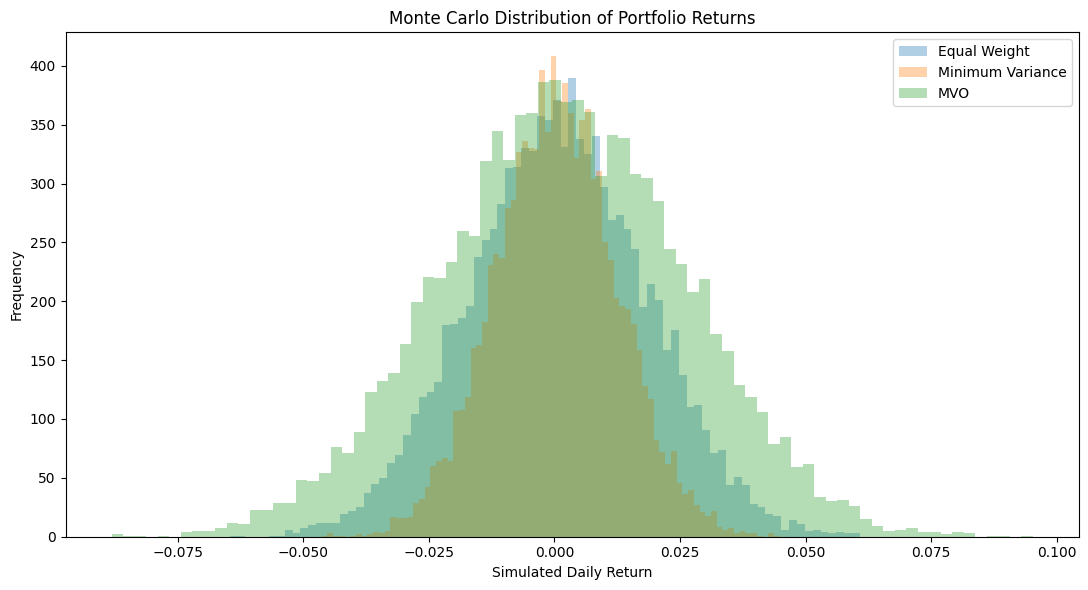

In [101]:
# ---------------------------------------------------------
# Monte Carlo distribution comparison
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

for portfolio in simulated_portfolio_returns.columns:

    plt.hist(
        simulated_portfolio_returns[portfolio],
        bins=80,
        alpha=0.35,
        label=portfolio
    )

plt.xlabel("Simulated Daily Return")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of Portfolio Returns")
plt.legend()

plt.tight_layout()
plt.show()

In [103]:
# ---------------------------------------------------------
# Final research summary
# ---------------------------------------------------------

final_results = performance_df.copy()

final_results["MC 5th Percentile"] = (
    mc_results_df["5th Percentile"]
)

final_results["MC Probability of Loss"] = (
    mc_results_df["Probability of Loss"]
)

final_results

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,MC 5th Percentile,MC Probability of Loss
Equal Weight,0.786255,0.198526,3.960457,-0.100642,-0.028202,0.4798
Minimum Variance,0.060252,0.142293,0.423438,-0.139560,-0.019535,0.4869
MVO,1.189586,0.281129,4.231464,-0.141989,-0.038474,0.4756


In [104]:
final_results.style.format({
    "Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Maximum Drawdown": "{:.2%}",
    "MC 5th Percentile": "{:.4%}",
    "MC Probability of Loss": "{:.2%}"
})

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,MC 5th Percentile,MC Probability of Loss
Equal Weight,78.63%,19.85%,3.960,-10.06%,-2.8202%,47.98%
Minimum Variance,6.03%,14.23%,0.423,-13.96%,-1.9535%,48.69%
MVO,118.96%,28.11%,4.231,-14.20%,-3.8474%,47.56%
